In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import joblib

sns.set_style("whitegrid")

In [2]:
# loading the dataset
diabetes = pd.read_csv("../data/diabetes.csv")
heart = pd.read_csv("../data/heart.csv")
anemia = pd.read_csv("../data/anemia.csv")
kidney = pd.read_csv("../data/kidney_disease.csv")

In [3]:
anemia.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [4]:
datasets = {
    "Diabetes": diabetes,
    "Heart": heart,
    "Anemia": anemia,
    "Kidney": kidney
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)
    print(df.head())
    print()

Diabetes
(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Heart
(1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       14

In [5]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum().sort_values(ascending=False).head(10))


Diabetes
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Heart
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
dtype: int64

Anemia
Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64

Kidney
rbc     152
rc      130
wc      105
pot      88
sod      87
pcv      70
pc       65
hemo     52
su       49
sg       47
dtype: int64


In [6]:
glucose_data = diabetes["Glucose"]

cholesterol_data = heart["chol"]

hemoglobin_anemia = anemia["Hemoglobin"]

hemoglobin_ckd = kidney["hemo"].dropna()

hemoglobin_data = pd.concat(
    [hemoglobin_anemia, hemoglobin_ckd],
    ignore_index=True
)

In [7]:
print("Glucose")
print(glucose_data.describe())

print("\nCholesterol")
print(cholesterol_data.describe())

print("\nHemoglobin")
print(hemoglobin_data.describe())

Glucose
count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

Cholesterol
count    1025.00000
mean      246.00000
std        51.59251
min       126.00000
25%       211.00000
50%       240.00000
75%       275.00000
max       564.00000
Name: chol, dtype: float64

Hemoglobin
count    1769.000000
mean       13.238383
std         2.218238
min         3.100000
25%        11.500000
50%        13.200000
75%        15.000000
max        17.800000
dtype: float64


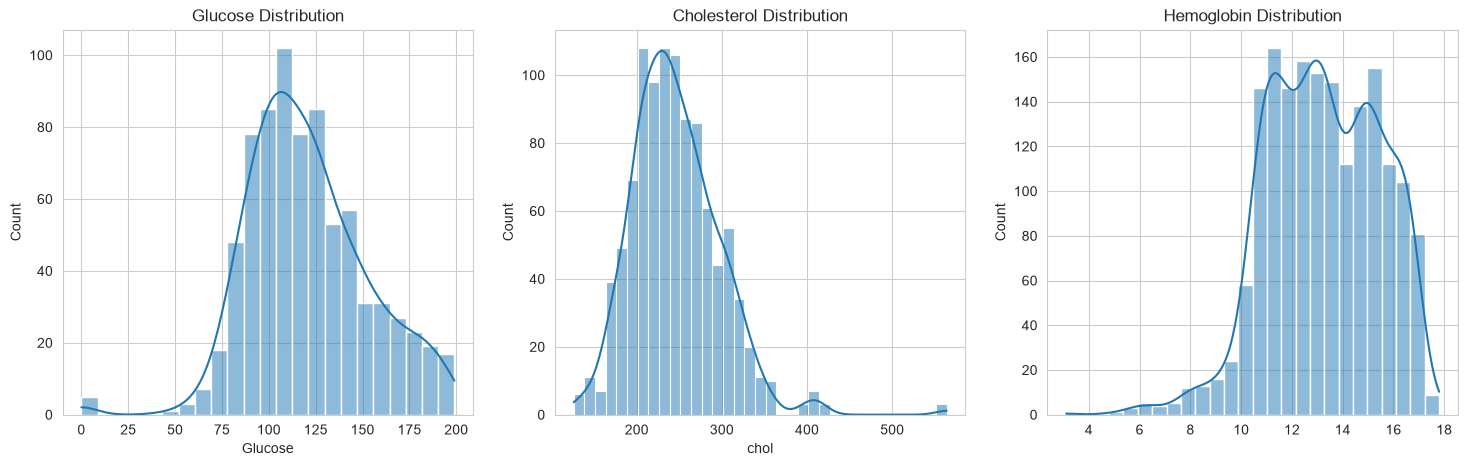

In [8]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(glucose_data, kde=True, ax=axes[0])
axes[0].set_title("Glucose Distribution")

sns.histplot(cholesterol_data, kde=True, ax=axes[1])
axes[1].set_title("Cholesterol Distribution")

sns.histplot(hemoglobin_data, kde=True, ax=axes[2])
axes[2].set_title("Hemoglobin Distribution")

plt.show()

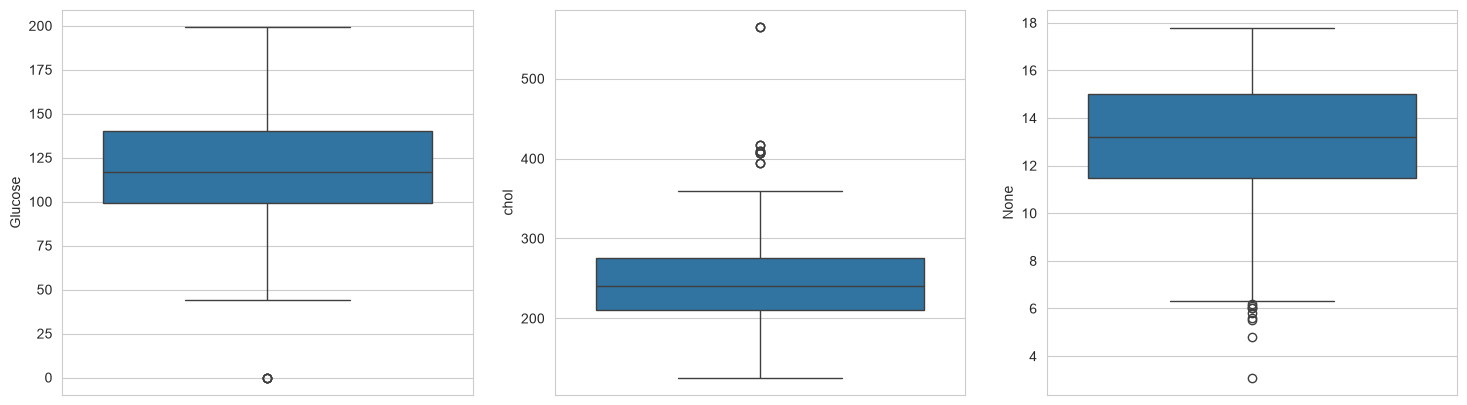

In [9]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=glucose_data, ax=axes[0])

sns.boxplot(y=cholesterol_data, ax=axes[1])

sns.boxplot(y=hemoglobin_data, ax=axes[2])

plt.show()

In [10]:
np.random.seed(42)

records = []

In [11]:
# Healthy ranges based on medical guidelines
for _ in range(1500):

    records.append([
        np.random.uniform(70,115),
        np.random.uniform(12,17),
        np.random.uniform(120,220),
        "Healthy"
    ])

In [12]:
#Prediabetes
for _ in range(1500):

    records.append([
        np.random.uniform(95,180),
        np.random.uniform(11,17),
        np.random.uniform(140,260),
        "Prediabetes Risk"
    ])

In [13]:
# Anemia
for _ in range(1500):

    records.append([
        np.random.uniform(70,130),
        np.random.uniform(7,13),
        np.random.uniform(120,250),
        "Anemia Risk"
    ])

In [14]:
# High Cholesterol
for _ in range(1500):

    records.append([
        np.random.uniform(70,140),
        np.random.uniform(11,17),
        np.random.uniform(190,350),
        "High Cholesterol Risk"
    ])

In [15]:
# Synthtic data generation using uniform distributions based on observed ranges in the datasets.
health_df = pd.DataFrame(
    records,
    columns=[
        "Glucose",
        "Haemoglobin",
        "Cholesterol",
        "Health_Status"
    ]
)

health_df.sample(5)

,Glucose,Haemoglobin,Cholesterol,Health_Status
3276,116.268163,10.967592,173.214840,Anemia Risk
5697,117.813493,16.773584,238.092337,High Cholesterol Risk
5533,124.189426,13.417999,305.608655,High Cholesterol Risk
4819,78.002618,15.441829,313.204875,High Cholesterol Risk
4520,74.471305,13.138507,286.172288,High Cholesterol Risk


In [16]:
health_df.to_csv("../data/synthetic_health_data.csv", index=False)  

In [17]:
health_df.shape

(6000, 4)

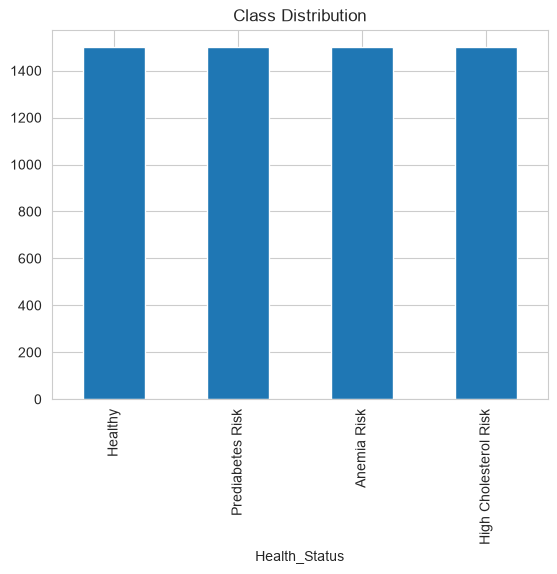

In [18]:
# Class distribution
health_df["Health_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.show()

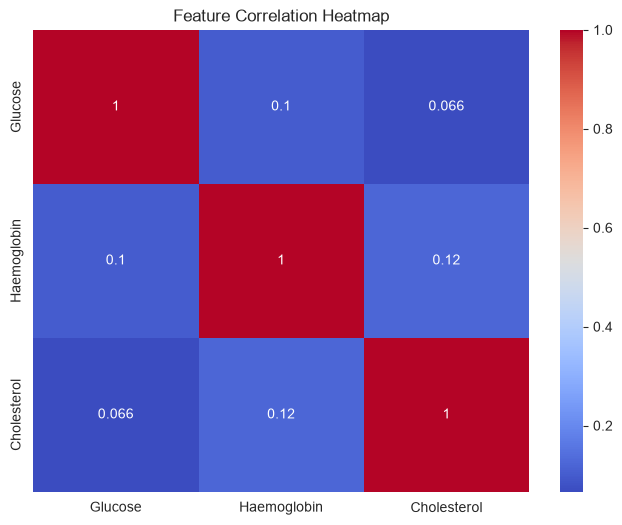

In [19]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    health_df.drop("Health_Status", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()  

In [20]:
# Label encoding the target variable

le = LabelEncoder()

health_df["Target"] = le.fit_transform(
    health_df["Health_Status"]
)

health_df.head()

,Glucose,Haemoglobin,Cholesterol,Health_Status,Target
0,86.854305,16.753572,193.199394,Healthy,1
1,96.939632,12.780093,135.599452,Healthy,1
2,72.613763,16.330881,180.111501,Healthy,1
3,101.863266,12.102922,216.990985,Healthy,1
4,107.459919,13.061696,138.182497,Healthy,1


In [21]:
# Add realistic noise
health_df.loc[
    health_df.sample(frac=0.08).index,
    "Glucose"
] += np.random.normal(0,15)
health_df.loc[
    health_df.sample(frac=0.08).index,
    "Haemoglobin"
] += np.random.normal(0,15)
health_df.loc[
    health_df.sample(frac=0.08).index,
    "Cholesterol"
] += np.random.normal(0,15)


In [22]:
health_df.sample(5)

,Glucose,Haemoglobin,Cholesterol,Health_Status,Target
2929,157.240223,11.526637,220.181679,Prediabetes Risk,3
5923,127.128790,15.250238,322.599083,High Cholesterol Risk,2
5144,111.685182,15.348257,261.251139,High Cholesterol Risk,2
5659,138.849156,11.596996,294.985889,High Cholesterol Risk,2
3553,103.889099,9.823030,113.620434,Anemia Risk,0


In [23]:
X = health_df[
    [
        "Glucose",
        "Haemoglobin",
        "Cholesterol"
    ]
]

y = health_df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric='mlogloss'
        )
}

In [25]:
#Benchmark function to evaluate all models using accuracy, precision, recall, and F1 score.
def evaluate_model(model, name):

    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_acc = accuracy_score(
        y_train,
        train_preds
    )

    test_acc = accuracy_score(
        y_test,
        test_preds
    )

    precision = precision_score(
        y_test,
        test_preds,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        test_preds,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        test_preds,
        average="weighted"
    )

    return {
        "Model": name,
        "Train Accuracy": round(train_acc,4),
        "Test Accuracy": round(test_acc,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1 Score": round(f1,4)
    }

In [26]:
results = []

for name, model in models.items():

    results.append(
        evaluate_model(
            model,
            name
        )
    )

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
3,Gradient Boosting,0.8715,0.8050,0.8168,0.8050,0.8021
2,Random Forest,1.0000,0.7875,0.7911,0.7875,0.7859
5,XGBoost,0.9840,0.7783,0.7799,0.7783,0.7772
4,AdaBoost,0.7794,0.7675,0.7791,0.7675,0.7691
1,Decision Tree,1.0000,0.7567,0.7571,0.7567,0.7567
0,Logistic Regression,0.7508,0.7208,0.7229,0.7208,0.7205


In [27]:
# Hyperparameter tuning - decision tree 
dt_params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

# random forest
rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

In [28]:
dt_grid = GridSearchCV(

    estimator=DecisionTreeClassifier(
        random_state=42
    ),

    param_grid=dt_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

dt_grid.fit(
    X_train,
    y_train
)

best_dt = dt_grid.best_estimator_

print(dt_grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [29]:
results.append(
    evaluate_model(
        best_dt,
        "Decision Tree Tuned"
    )
)

In [30]:
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7508,0.7208,0.7229,0.7208,0.7205
1,Decision Tree,1.0000,0.7567,0.7571,0.7567,0.7567
2,Random Forest,1.0000,0.7875,0.7911,0.7875,0.7859
3,Gradient Boosting,0.8715,0.8050,0.8168,0.8050,0.8021
4,AdaBoost,0.7794,0.7675,0.7791,0.7675,0.7691
5,XGBoost,0.9840,0.7783,0.7799,0.7783,0.7772


In [31]:
rf_grid = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=rf_params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

best_rf = rf_grid.best_estimator_

print(
    rf_grid.best_params_
)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [32]:
results.append(
    evaluate_model(
        best_rf,
        "Random Forest Tuned"
    )
)

In [33]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
3,Gradient Boosting,0.8715,0.8050,0.8168,0.8050,0.8021
2,Random Forest,1.0000,0.7875,0.7911,0.7875,0.7859
7,Random Forest Tuned,0.8900,0.7867,0.7990,0.7867,0.7837
6,Decision Tree Tuned,0.8535,0.7842,0.7935,0.7842,0.7816
5,XGBoost,0.9840,0.7783,0.7799,0.7783,0.7772
4,AdaBoost,0.7794,0.7675,0.7791,0.7675,0.7691
1,Decision Tree,1.0000,0.7567,0.7571,0.7567,0.7567
0,Logistic Regression,0.7508,0.7208,0.7229,0.7208,0.7205


In [34]:
results_df["Overfitting Gap"] = (
    results_df["Train Accuracy"] -
    results_df["Test Accuracy"]
)

results_df.sort_values(
    by="Overfitting Gap",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfitting Gap
1,Decision Tree,1.0000,0.7567,0.7571,0.7567,0.7567,0.2433
2,Random Forest,1.0000,0.7875,0.7911,0.7875,0.7859,0.2125
5,XGBoost,0.9840,0.7783,0.7799,0.7783,0.7772,0.2057
7,Random Forest Tuned,0.8900,0.7867,0.7990,0.7867,0.7837,0.1033
6,Decision Tree Tuned,0.8535,0.7842,0.7935,0.7842,0.7816,0.0693
3,Gradient Boosting,0.8715,0.8050,0.8168,0.8050,0.8021,0.0665
0,Logistic Regression,0.7508,0.7208,0.7229,0.7208,0.7205,0.0300
4,AdaBoost,0.7794,0.7675,0.7791,0.7675,0.7691,0.0119


In [35]:
best_model_name = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).iloc[0]["Model"]

print(
    f"Best Model: {best_model_name}"
)

Best Model: Gradient Boosting


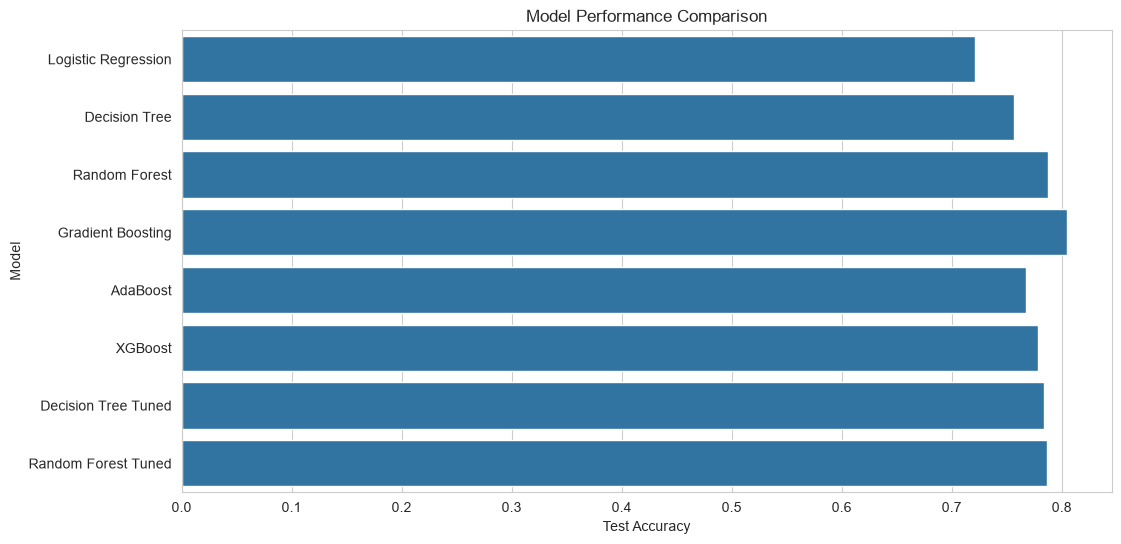

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Test Accuracy",
    y="Model"
)

plt.title(
    "Model Performance Comparison"
)

plt.show()

In [ ]:
final_model = GradientBoostingClassifier(
    random_state=42
)
final_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [39]:
preds = final_model.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.88      0.83      0.85       300
           1       0.72      0.98      0.83       300
           2       0.82      0.75      0.79       300
           3       0.85      0.66      0.74       300

    accuracy                           0.81      1200
   macro avg       0.82      0.81      0.80      1200
weighted avg       0.82      0.81      0.80      1200



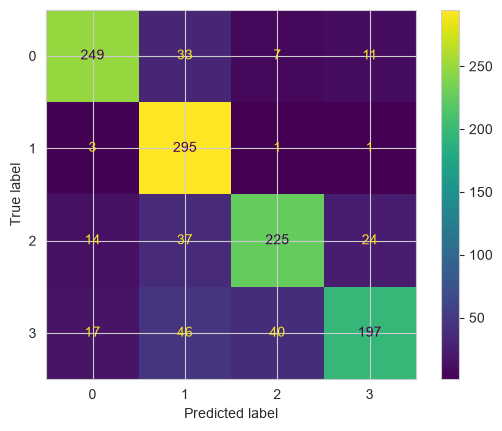

In [40]:
cm = confusion_matrix(
    y_test,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [41]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":final_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Haemoglobin,0.389762
2,Cholesterol,0.332628
0,Glucose,0.277610


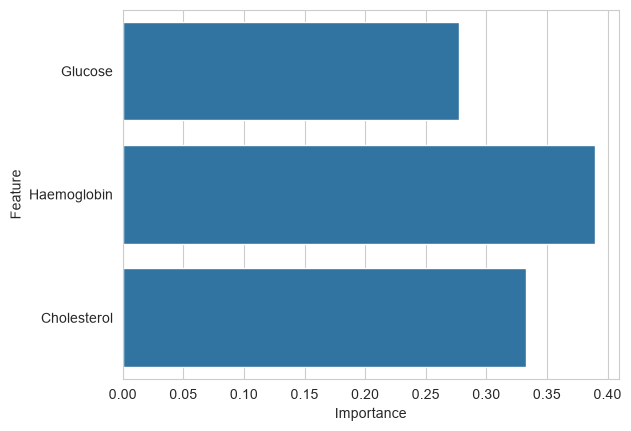

In [42]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.show()

In [43]:
joblib.dump(
    final_model,
    "../models/health_model.pkl"
)

joblib.dump(
    le,
    "../models/label_encoder.pkl"
)

print("Model Saved")

Model Saved


In [44]:
def predict_health(
        glucose,
        haemoglobin,
        cholesterol):

    pred = final_model.predict(
        [[
            glucose,
            haemoglobin,
            cholesterol
        ]]
    )[0]

    return le.inverse_transform(
        [pred]
    )[0]

In [45]:
predict_health(
    glucose=170,
    haemoglobin=14,
    cholesterol=180
)

'Prediabetes Risk'